In [15]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
plt.style.use("seaborn-v0_8-whitegrid")

In [16]:
gammas = [0.0, 0.2, 0.4, 0.5, 0.6, 0.75, 0.9, 0.95, 0.99]

In [17]:
data = {i: pd.read_csv(f"gamma{str(int(i * 100)).zfill(2)}/results/evaluation.csv") for i in gammas}

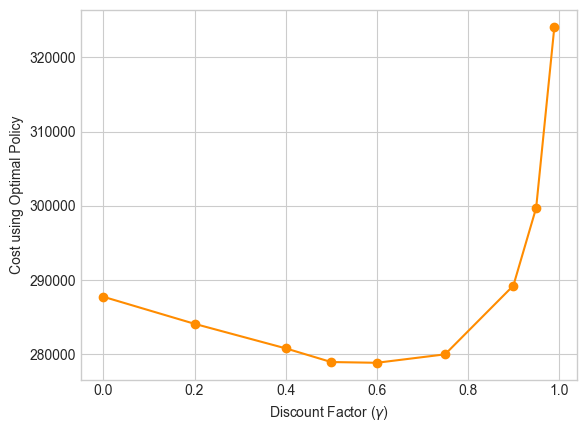

In [23]:
fig, ax = plt.subplots(1)
ax.scatter(gammas, [data[i]["Stage 21"].mean() for i in gammas], c='darkorange')
ax.plot(gammas, [data[i]["Stage 21"].mean() for i in gammas], c='darkorange')
ax.set_xlabel(r"Discount Factor ($\gamma$)")
ax.set_ylabel("Cost using Optimal Policy")
fig.savefig("vary_discount_rate.pdf")

/var/folders/wn/3cxs5bc91hsbl4gwt8j95d0h0000gp/T/ipykernel_3455/1222020865.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axarr[0].set_xticklabels(axarr[0].get_xticklabels(), rotation=90)


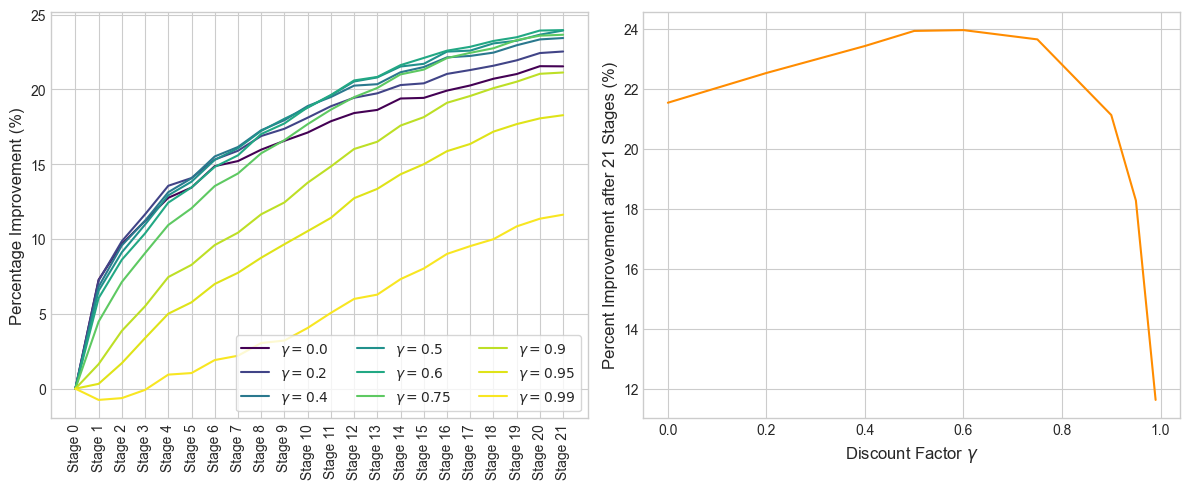

In [37]:
fig, axarr = plt.subplots(1, 2, figsize=(12, 5))
cmap = mpl.colormaps['viridis']
for i in gammas:
    axarr[0].plot((1 - (data[i].mean() / data[i].mean()['Stage 0'])) * 100, c=cmap(i), label=fr"$\gamma = {i}$")
axarr[0].set_ylabel("Percentage Improvement (%)", fontsize=12)
axarr[0].legend(frameon=True, ncol=3)
axarr[0].set_xticklabels(axarr[0].get_xticklabels(), rotation=90)

axarr[1].plot(
    gammas,
    [((data[i].mean()['Stage 0'] - data[i].mean()['Stage 21']) / data[i].mean()['Stage 0']) * 100 for i in gammas],
    c='darkorange'
)
axarr[1].set_xlabel(r"Discount Factor $\gamma$", fontsize=12)
axarr[1].set_ylabel("Percent Improvement after 21 Stages (%)", fontsize=12)
plt.tight_layout()
fig.savefig("vary_gamma.pdf")

In [23]:
(data[0.0].mean()['Stage 1'] - data[0.0].mean()['Stage 21']) / data[0.0].mean()['Stage 1']

np.float64(0.15384765550615817)